<a href="https://colab.research.google.com/github/DiPolanski/IA/blob/main/outliers_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Importar pacotes
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# **Carregar os dados**

In [6]:
df_original = pd.read_csv("/content/dados_balanceados.csv", sep= ",")

# Nomear as colunas
df_original.columns = [['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']]

#Vizualizar a tabela
df_original

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.300000,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.500000,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.400000,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.800000,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.600000,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,54,1,0,120,187,0,0,112,0,1.407981,1,1,2,0
326,59,1,0,129,206,0,0,132,0,2.390316,1,1,2,0
327,44,1,0,127,247,0,0,143,0,0.349986,1,2,3,0
328,59,1,1,153,284,0,0,147,0,1.930803,1,1,3,0


In [10]:
# Checando as infos
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   (age,)       330 non-null    int64  
 1   (sex,)       330 non-null    int64  
 2   (cp,)        330 non-null    int64  
 3   (trestbps,)  330 non-null    int64  
 4   (chol,)      330 non-null    int64  
 5   (fbs,)       330 non-null    int64  
 6   (restecg,)   330 non-null    int64  
 7   (thalach,)   330 non-null    int64  
 8   (exang,)     330 non-null    int64  
 9   (oldpeak,)   330 non-null    float64
 10  (slope,)     330 non-null    int64  
 11  (ca,)        330 non-null    int64  
 12  (thal,)      330 non-null    int64  
 13  (target,)    330 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 36.2 KB


In [9]:
# Verificando como está a base
df_original.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,54.363636,0.690909,0.915152,132.181818,246.793939,0.136364,0.493939,148.606061,0.324242,1.076140,1.351515,0.724242,2.312121,0.500000
std,8.892872,0.462821,1.021984,17.539629,51.652627,0.343695,0.524442,22.775953,0.468802,1.163054,0.626721,0.998336,0.620940,0.500759
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.500000,1.000000,1.000000,130.000000,241.500000,0.000000,0.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,0.500000
75%,60.000000,1.000000,2.000000,140.000000,277.750000,0.000000,1.000000,165.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
# Pega todos os dados, menos target
df2 = df_original.iloc[:, 0:13]
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


# **BOXPLOTS**

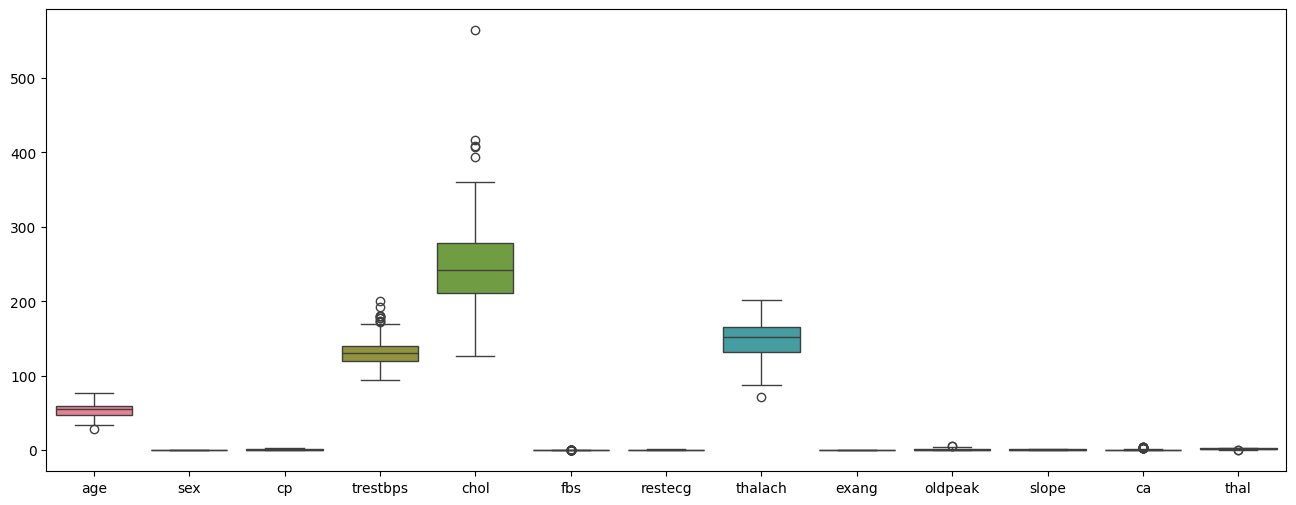

In [12]:
# Ajustando o tamanho
plt.figure(figsize=(16, 6))
ax = sns.boxplot(data=df2)


Possíver ver uma distorção, devido a diferença de valores entre as variáveis

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   (age,)       330 non-null    int64  
 1   (sex,)       330 non-null    int64  
 2   (cp,)        330 non-null    int64  
 3   (trestbps,)  330 non-null    int64  
 4   (chol,)      330 non-null    int64  
 5   (fbs,)       330 non-null    int64  
 6   (restecg,)   330 non-null    int64  
 7   (thalach,)   330 non-null    int64  
 8   (exang,)     330 non-null    int64  
 9   (oldpeak,)   330 non-null    float64
 10  (slope,)     330 non-null    int64  
 11  (ca,)        330 non-null    int64  
 12  (thal,)      330 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 33.6 KB


##**BOXSPLOT por variável**

('age',) : int64
('sex',) : int64
('cp',) : int64
('trestbps',) : int64
('chol',) : int64
('fbs',) : int64
('restecg',) : int64
('thalach',) : int64
('exang',) : int64
('oldpeak',) : float64
('slope',) : int64
('ca',) : int64
('thal',) : int64


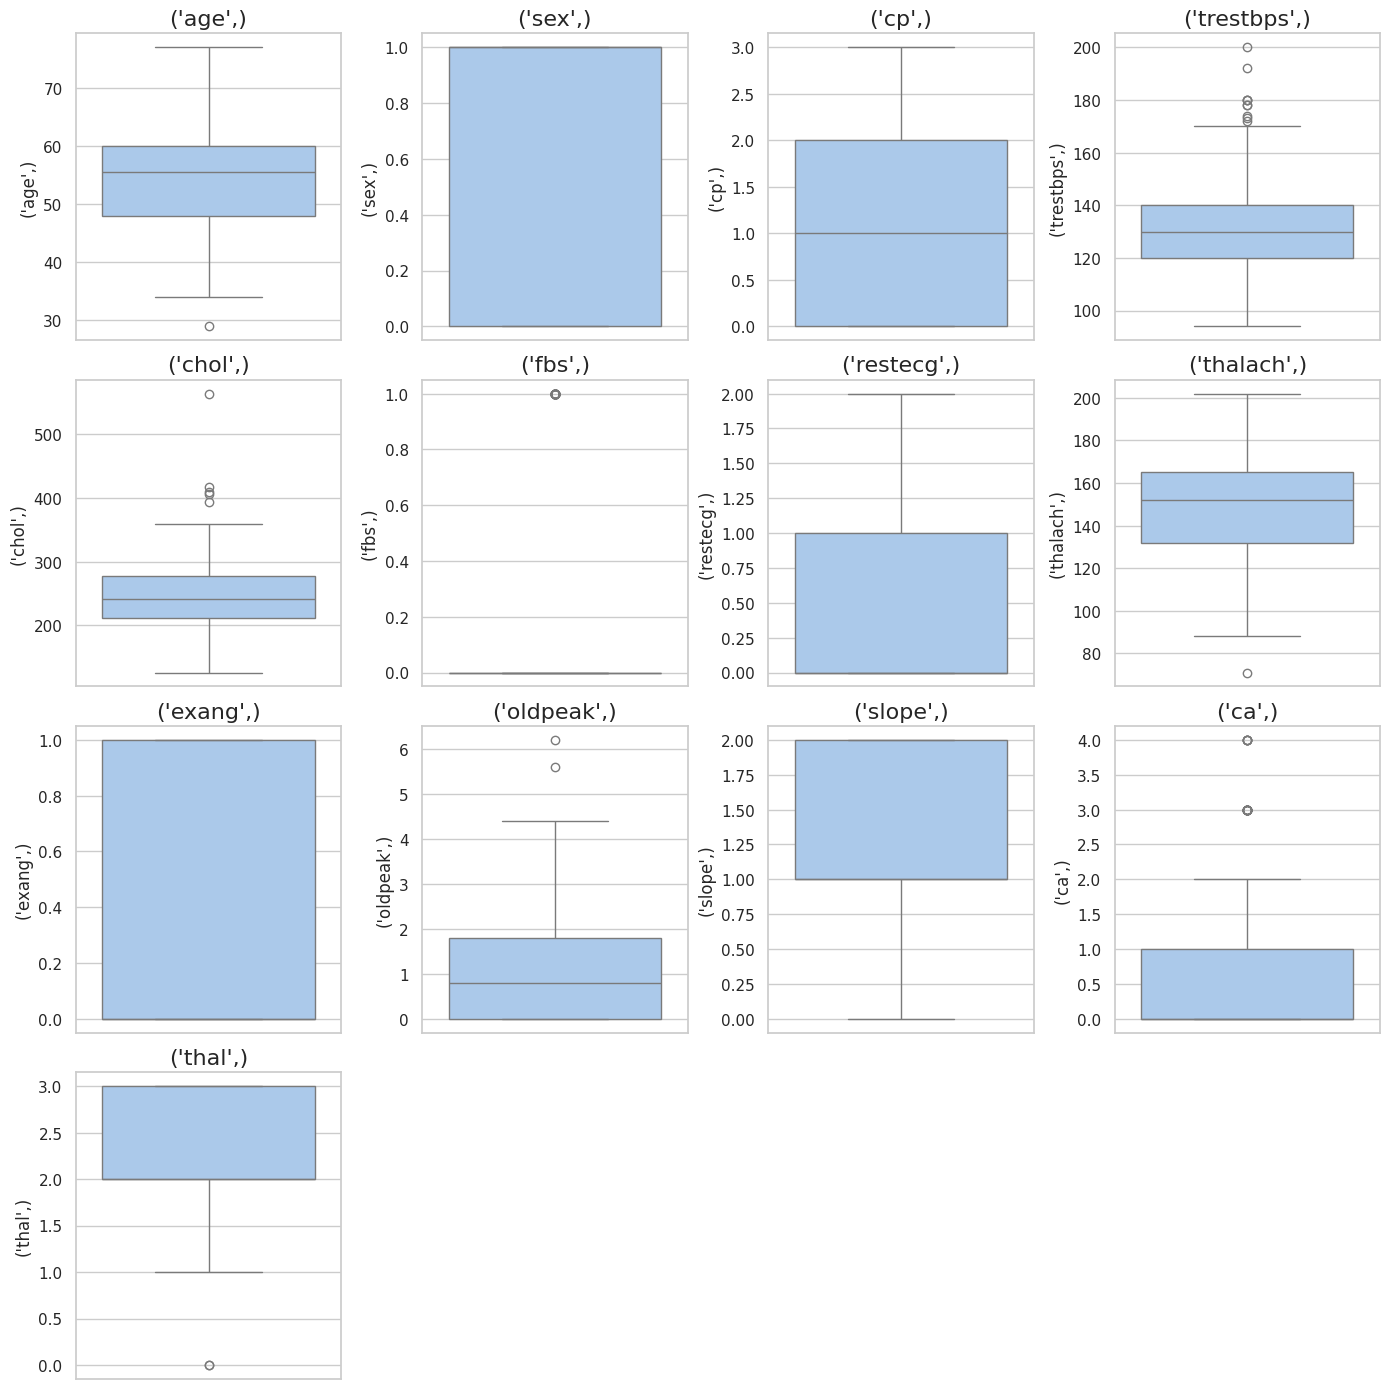

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificação de variáveis numéricas
variaveis_numericas = []
for i in df2.columns[0:13].tolist():
    if df2.dtypes[i] == "int64" or df2.dtypes[i] == "float64":
        print(i, ":", df2.dtypes[i])
        variaveis_numericas.append(i)

# Ajustes no estilo e na paleta
sns.set_theme(style="whitegrid", palette="pastel")

# Ajustes nos parâmetros de visualização
plt.rcParams["figure.figsize"] = [14.00, 14.00]
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 16

# Criação dos subplots
f, axes = plt.subplots(4, 4)  # Cria uma grade de 4x4
plt.subplots_adjust(hspace=0.5, wspace=0.5)  # Ajusta de espaçamento

linha = 0
coluna = 0

# Loop para criar os boxplots
for i, var in enumerate(variaveis_numericas):
    sns.boxplot(data=df2, y=var, ax=axes[linha][coluna])  # Ajuste para acessar corretamente os eixos
    axes[linha][coluna].set_title(var)  # Título
    axes[linha][coluna].tick_params(axis="x", rotation=45)
    coluna += 1
    if coluna == 4:
        linha += 1
        coluna = 0

# Remove subplots vazios
for j in range(len(variaveis_numericas), 16):
    f.delaxes(axes[j // 4][j % 4])

plt.show()


É possível então, encontrar diversos outliers.

In [20]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-2.0.2-py3-none-any.whl size=198469 sha256=0bc50ce0bee9fc65f3612243085beda3ca270bbfd6329b8b7145a8ceb47507dd
  Stored in directory: /root/.cache/pip/wheels/77/c2/20/34d1f15b41b701ba69f42a32304825810d680754d509f91391
Successfully built pyod


# **Tratando os outliers.**

In [21]:
from pyod.models.knn import KNN

In [22]:
#Detector será responsável por identificar os outliers
detector = KNN()

detector.fit(df2)

KNN(algorithm='auto', contamination=0.1, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [23]:
# 0 = NÃO outlier
# 1 = Outlier

previsoes = detector.labels_
previsoes

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

In [25]:
#Verificar qauntos Outliers
np.unique(previsoes, return_counts=True)

(array([0, 1]), array([297,  33]))

In [26]:
# Verifica a distancia de fato de cada outlier

confianca_previsoes = detector.decision_scores_
confianca_previsoes

array([ 16.1       ,  20.35313244,  15.23023309,  15.85433695,
        29.5086428 ,  14.31782106,  17.69208863,  14.32654878,
        31.38486897,  27.62173058,  12.38709005,  21.00380918,
        13.42981757,  19.05885621,  17.66606917,  13.65869686,
        25.65151068,  18.22086716,  20.15167487,  16.00124995,
        14.39618005,  12.84678948,  14.62873884,  17.45537167,
        20.54166498,  25.30533541,  15.34796403,  19.63771881,
        66.91068674,  12.87012043,  15.84297952,  23.21551206,
        18.39673884,  15.18848248,  13.78334958,  17.16275036,
        13.67479433,  13.5114766 ,  18.62793601,  40.07692603,
        16.72393494,  13.00153837,  16.77021169,  12.13095215,
        26.80596948,  21.9089023 ,  14.76617757,  12.72792206,
        17.92344833,  13.5114766 ,  10.95490758,  20.48511655,
        15.58845727,  43.61009058,  18.        ,   9.0354856 ,
        18.16590212,  17.8605711 ,  22.        ,  15.90597372,
        23.40939982,  21.42428529,  27.87400222,  18.97

In [28]:
# Vamos seprar os outliers
outliers = []
for i in range(len(previsoes)):
  if previsoes[i] == 1:
    outliers.append(i)

print(outliers)

[4, 8, 28, 39, 53, 62, 72, 84, 85, 96, 110, 111, 136, 151, 162, 180, 195, 204, 215, 220, 223, 234, 243, 246, 248, 253, 260, 266, 272, 279, 288, 297, 301]


In [30]:
# Vamos filtrar todos os outliers agora da base original
lista_outliers = df_original.iloc[outliers, :]
lista_outliers

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
28,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
39,65,0,2,160,360,0,0,151,0,0.8,2,0,2,1
53,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
62,52,1,3,118,186,0,0,190,0,0.0,1,0,1,1
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
84,42,0,0,102,265,0,0,122,0,0.6,1,0,2,1
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
96,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1


In [32]:
lista_outliers.shape

(33, 14)

# **Eliminando os Outliers**

In [34]:

base_sem_outliers = df_original.drop(outliers)
base_sem_outliers

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.300000,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.500000,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.400000,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.800000,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.400000,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,54,1,0,120,187,0,0,112,0,1.407981,1,1,2,0
326,59,1,0,129,206,0,0,132,0,2.390316,1,1,2,0
327,44,1,0,127,247,0,0,143,0,0.349986,1,2,3,0
328,59,1,1,153,284,0,0,147,0,1.930803,1,1,3,0


In [35]:
base_sem_outliers.to_csv('base_sem_outliers.csv', index=False)